In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import joblib

In [3]:
df = pd.read_csv("Cleaned_Bengaluru_House_Data_final.csv")

df.head()

,total_sqft,bath,balcony,price,bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,availability_Ready,location_Bannerghatta Road,...,location_Kanakpura Road,location_Marathahalli,location_Other,location_Raja Rajeshwari Nagar,location_Rajaji Nagar,location_Sarjapur Road,location_Thanisandra,location_Uttarahalli,location_Whitefield,location_Yelahanka
0,1056.0,2.0,1.0,39.07,2,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1440.0,2.0,3.0,62.00,3,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,1521.0,3.0,1.0,95.00,3,False,False,True,True,False,...,False,False,True,False,False,False,False,False,False,False
3,1200.0,2.0,1.0,51.00,2,False,False,True,True,False,...,False,False,True,False,False,False,False,False,False,False
4,1170.0,2.0,1.0,38.00,2,False,False,True,True,False,...,False,False,False,False,False,False,False,False,True,False


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9790
Columns: 29


In [5]:
print(df.columns)

Index(['total_sqft', 'bath', 'balcony', 'price', 'bhk',
       'area_type_Carpet  Area', 'area_type_Plot  Area',
       'area_type_Super built-up  Area', 'availability_Ready',
       'location_Bannerghatta Road', 'location_Bellandur',
       'location_Electronic City', 'location_Electronic City Phase II',
       'location_Electronics City Phase 1', 'location_Haralur Road',
       'location_Hebbal', 'location_Hennur Road', 'location_Hoodi',
       'location_KR Puram', 'location_Kanakpura Road', 'location_Marathahalli',
       'location_Other', 'location_Raja Rajeshwari Nagar',
       'location_Rajaji Nagar', 'location_Sarjapur  Road',
       'location_Thanisandra', 'location_Uttarahalli', 'location_Whitefield',
       'location_Yelahanka'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9790 entries, 0 to 9789
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   total_sqft                         9790 non-null   float64
 1   bath                               9790 non-null   float64
 2   balcony                            9790 non-null   float64
 3   price                              9790 non-null   float64
 4   bhk                                9790 non-null   int64  
 5   area_type_Carpet  Area             9790 non-null   bool   
 6   area_type_Plot  Area               9790 non-null   bool   
 7   area_type_Super built-up  Area     9790 non-null   bool   
 8   availability_Ready                 9790 non-null   bool   
 9   location_Bannerghatta Road         9790 non-null   bool   
 10  location_Bellandur                 9790 non-null   bool   
 11  location_Electronic City           9790 non-null   bool 

In [7]:
df.isnull().sum()

total_sqft                           0
bath                                 0
balcony                              0
price                                0
bhk                                  0
area_type_Carpet  Area               0
area_type_Plot  Area                 0
area_type_Super built-up  Area       0
availability_Ready                   0
location_Bannerghatta Road           0
location_Bellandur                   0
location_Electronic City             0
location_Electronic City Phase II    0
location_Electronics City Phase 1    0
location_Haralur Road                0
location_Hebbal                      0
location_Hennur Road                 0
location_Hoodi                       0
location_KR Puram                    0
location_Kanakpura Road              0
location_Marathahalli                0
location_Other                       0
location_Raja Rajeshwari Nagar       0
location_Rajaji Nagar                0
location_Sarjapur  Road              0
location_Thanisandra     

In [8]:
df.describe()

,total_sqft,bath,balcony,price,bhk
count,9790.000000,9790.000000,9790.00000,9790.000000,9790.000000
mean,1260.165946,2.251788,1.56619,68.369384,2.400715
std,338.133411,0.628140,0.76285,29.945509,0.650090
min,375.000000,1.000000,0.00000,8.440000,1.000000
25%,1066.000000,2.000000,1.00000,46.000000,2.000000
50%,1215.000000,2.000000,2.00000,62.000000,2.000000
75%,1474.500000,3.000000,2.00000,85.000000,3.000000
max,2265.000000,4.000000,3.00000,155.000000,4.000000


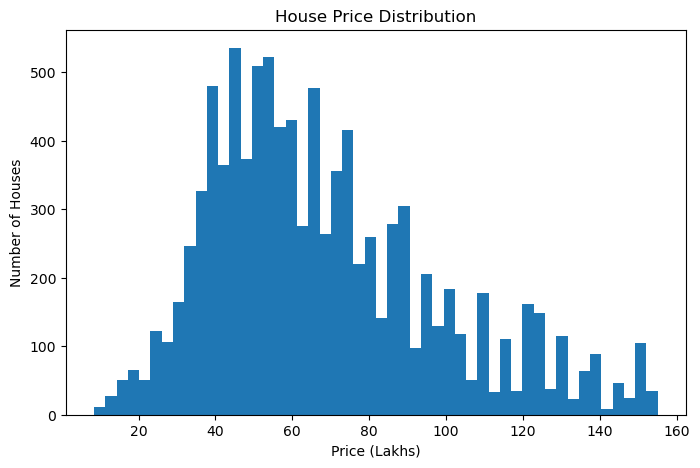

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df["price"], bins=50)

plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Houses")
plt.title("House Price Distribution")

plt.show()

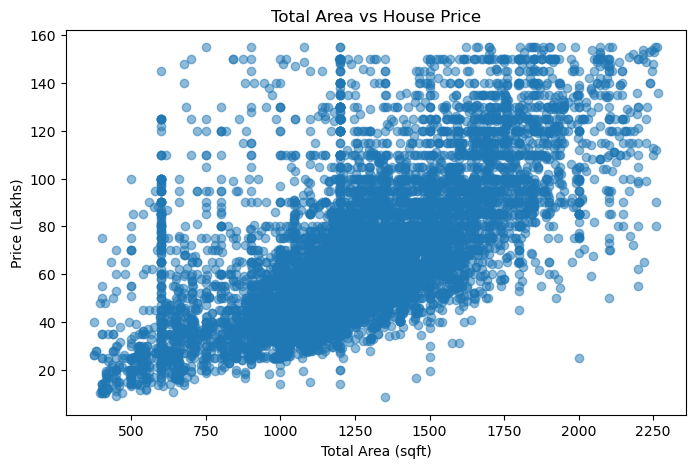

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(df["total_sqft"], df["price"], alpha=0.5)

plt.xlabel("Total Area (sqft)")
plt.ylabel("Price (Lakhs)")
plt.title("Total Area vs House Price")

plt.show()

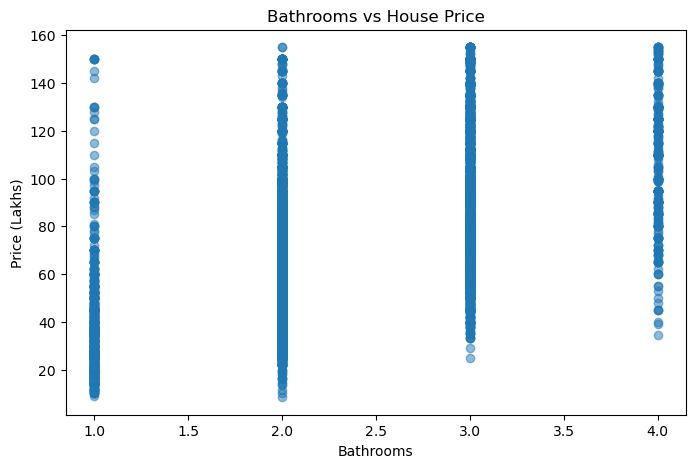

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(df["bath"], df["price"], alpha=0.5)

plt.xlabel("Bathrooms")
plt.ylabel("Price (Lakhs)")
plt.title("Bathrooms vs House Price")

plt.show()

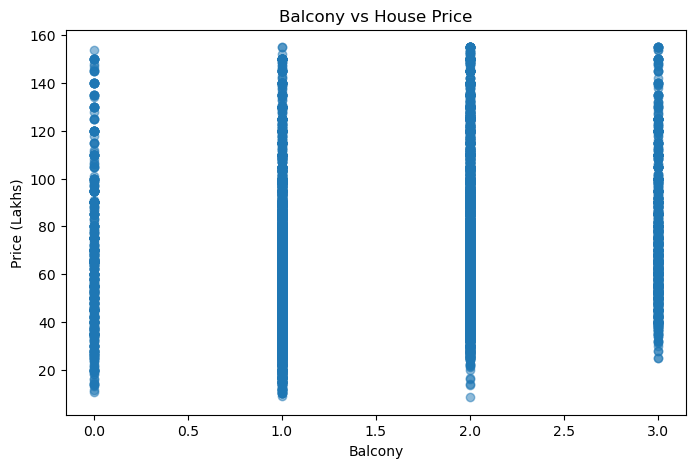

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(df["balcony"], df["price"], alpha=0.5)

plt.xlabel("Balcony")
plt.ylabel("Price (Lakhs)")
plt.title("Balcony vs House Price")

plt.show()

In [15]:
X = df.drop("price", axis=1)
y = df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9790, 28)
y shape: (9790,)


In [16]:
print("Features used by the model:")
print(X.columns.tolist())

Features used by the model:
['total_sqft', 'bath', 'balcony', 'bhk', 'area_type_Carpet  Area', 'area_type_Plot  Area', 'area_type_Super built-up  Area', 'availability_Ready', 'location_Bannerghatta Road', 'location_Bellandur', 'location_Electronic City', 'location_Electronic City Phase II', 'location_Electronics City Phase 1', 'location_Haralur Road', 'location_Hebbal', 'location_Hennur Road', 'location_Hoodi', 'location_KR Puram', 'location_Kanakpura Road', 'location_Marathahalli', 'location_Other', 'location_Raja Rajeshwari Nagar', 'location_Rajaji Nagar', 'location_Sarjapur  Road', 'location_Thanisandra', 'location_Uttarahalli', 'location_Whitefield', 'location_Yelahanka']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7832, 28)
Testing data: (1958, 28)


In [18]:
scaler = MinMaxScaler()

In [19]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [20]:
y_train_np = y_train.to_numpy()

y_test_np = y_test.to_numpy()

In [21]:
model = LinearRegression()

In [22]:
model.fit(X_train_scaled, y_train_np)

LinearRegression()

In [23]:
y_pred_lr = model.predict(X_test_scaled)

print(y_pred_lr[:10])

[55.64750828 69.13530627 93.05021118 59.93562717 55.85576391 24.01518477
 45.85739057 98.30894637 65.07039876 61.56535139]


In [24]:
mse_lr = mean_squared_error(y_test_np, y_pred_lr)

r2_lr = r2_score(y_test_np, y_pred_lr)

print("========== LINEAR REGRESSION ==========")
print("MSE:", mse_lr)
print("R2 Score:", r2_lr)

========== LINEAR REGRESSION ==========
MSE: 427.11862704076304
R2 Score: 0.5481287182103243


In [25]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, weight in zip(X.columns, model.coef_):
    print(feature, ":", weight)

Intercept: 22.258301499225524

Coefficients:
total_sqft : 95.5168343688294
bath : 27.613186145964473
balcony : -3.089671846956392
bhk : -1.9667276363771982
area_type_Carpet  Area : 8.538908311840176
area_type_Plot  Area : 23.00030965357544
area_type_Super built-up  Area : -0.4080201583916964
availability_Ready : 1.7957394425927726
location_Bannerghatta Road : -9.841535593173393
location_Bellandur : -7.999077944431011
location_Electronic City : -16.861646529011086
location_Electronic City Phase II : -27.263241743310598
location_Electronics City Phase 1 : -14.831286874290049
location_Haralur Road : -5.152548144114925
location_Hebbal : 3.7988149084480107
location_Hennur Road : -5.929918073705518
location_Hoodi : -2.1522312112051503
location_KR Puram : -21.001517143399887
location_Kanakpura Road : -12.151322050283484
location_Marathahalli : -5.355203763856022
location_Other : -10.4071267854483
location_Raja Rajeshwari Nagar : -23.264985602618808
location_Rajaji Nagar : 28.746173266905487
l

In [26]:
weights = np.zeros(X_train_scaled.shape[1])

bias = 0

learning_rate = 0.01

epochs = 1000

n = len(X_train_scaled)

loss_history = []

In [27]:
for epoch in range(epochs):

    # Prediction
    y_pred = np.dot(X_train_scaled, weights) + bias

    # Error
    error = y_pred - y_train_np

    # Gradients
    dw = (2 / n) * np.dot(X_train_scaled.T, error)

    db = (2 / n) * np.sum(error)

    # Update weights
    weights = weights - learning_rate * dw

    # Update bias
    bias = bias - learning_rate * db

    # Calculate loss
    mse = np.mean(error ** 2)

    loss_history.append(mse)

In [28]:
y_pred_gd = np.dot(X_test_scaled, weights) + bias

print(y_pred_gd[:10])

[56.52603676 72.5600154  88.96703241 72.96458756 58.30330085 28.13727542
 53.57133184 91.11791335 65.79569495 67.59230775]


In [29]:
mse_gd = mean_squared_error(y_test_np, y_pred_gd)

r2_gd = r2_score(y_test_np, y_pred_gd)

print("========== GRADIENT DESCENT ==========")
print("MSE:", mse_gd)
print("R2 Score:", r2_gd)

========== GRADIENT DESCENT ==========
MSE: 525.7855722130294
R2 Score: 0.44374376245654823


In [30]:
print("Bias:", bias)

print("\nWeights:")

for feature, weight in zip(X.columns, weights):
    print(feature, ":", weight)

Bias: 20.047611423206902

Weights:
total_sqft : 39.06744315381441
bath : 29.428869097470894
balcony : 6.0927247462536105
bhk : 25.13300944866636
area_type_Carpet  Area : 0.9467416157846199
area_type_Plot  Area : 13.80057611325053
area_type_Super built-up  Area : 0.08826490029076582
availability_Ready : 1.4945370080126017
location_Bannerghatta Road : 1.1663267061598372
location_Bellandur : 0.9879997395001984
location_Electronic City : -2.658028245634269
location_Electronic City Phase II : -3.0358100969456063
location_Electronics City Phase 1 : -0.2678106527995192
location_Haralur Road : 1.8144296955551347
location_Hebbal : 4.011871738265999
location_Hennur Road : 2.6476384106455733
location_Hoodi : 2.2184005765939374
location_KR Puram : -0.9696284451891184
location_Kanakpura Road : 0.6625357987703825
location_Marathahalli : 2.369925593009066
location_Other : 0.4071545855682704
location_Raja Rajeshwari Nagar : -2.7861767455301933
location_Rajaji Nagar : 1.6328137710200064
location_Sarjap

In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Gradient Descent"
    ],
    
    "MSE": [
        mse_lr,
        mse_gd
    ],
    
    "R2 Score": [
        r2_lr,
        r2_gd
    ]
})

comparison

,Model,MSE,R2 Score
0,Linear Regression,427.118627,0.548129
1,Gradient Descent,525.785572,0.443744


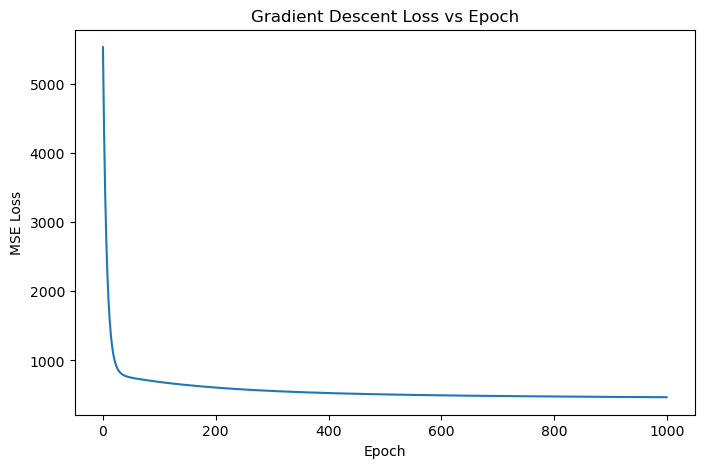

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Loss vs Epoch")

plt.show()

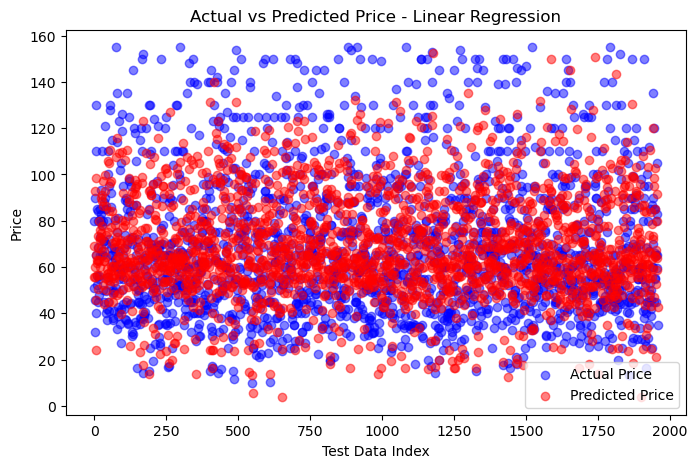

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(range(len(y_test_np)), y_test_np,
            alpha=0.5, color='blue', label='Actual Price')

plt.scatter(range(len(y_pred_lr)), y_pred_lr,
            alpha=0.5, color='red', label='Predicted Price')

plt.xlabel("Test Data Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted Price - Linear Regression")
plt.legend()

plt.show()

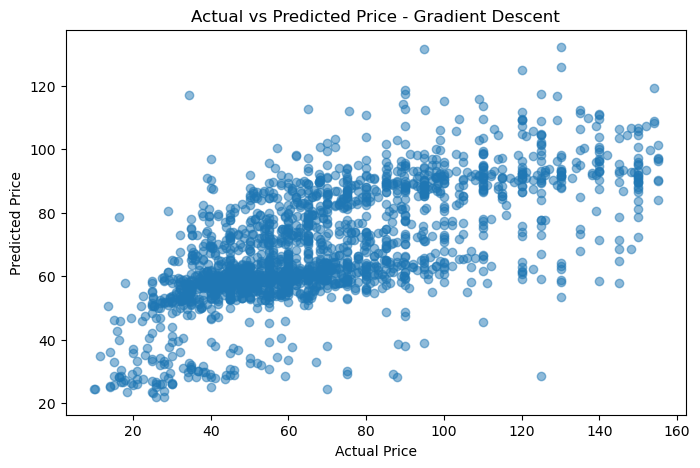

In [37]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test_np, y_pred_gd, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price - Gradient Descent")

plt.show()

In [34]:
joblib.dump(model, "house_price_model.pkl")

print("Linear Regression model saved successfully!")

Linear Regression model saved successfully!


In [35]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [36]:
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


In [37]:
loaded_model = joblib.load("house_price_model.pkl")

loaded_scaler = joblib.load("scaler.pkl")

X_test_again = loaded_scaler.transform(X_test)

prediction = loaded_model.predict(X_test_again)

print("First 5 predictions:")
print(prediction[:5])

First 5 predictions:
[55.64750828 69.13530627 93.05021118 59.93562717 55.85576391]
